In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sys.path.insert(0, str(Path(".").resolve()))
from analysis_helpers import analyseWER

In [2]:
DATA_DIR    = Path("data")
TARGET_FILE = "transcript_experiment.wav"
TEMPERATURES = [0.0, 1.0]
N_TAKES     = 5
MIN_TAKES   = 2   # minimum takes per temperature to be included


def has_reliability_data(folder):
    for temp in TEMPERATURES:
        temp_tag = f"temp{int(temp)}"
        count = sum(
            1 for take in range(1, N_TAKES + 1)
            if (folder / "analysis" / TARGET_FILE.replace(".wav", f"_{temp_tag}_take{take}.json")).exists()
        )
        if count < MIN_TAKES:
            return False
    return True


def short_name(folder_name):
    name = folder_name.removeprefix("experiment_")
    head, _, tail = name.rpartition("_")
    return head if tail.isdigit() else name


participants = sorted(
    [f for f in DATA_DIR.iterdir() if f.is_dir() and has_reliability_data(f)],
    key=lambda f: short_name(f.name).lower(),
)

print(f"Participants with reliability data ({len(participants)}):")
for p in participants:
    print(f"  {short_name(p.name)}")

Participants with reliability data (6):
  Albert Barreiro
  enric2
  Jack
  Julien
  Riri
  RRT


In [3]:
wer_data = {}


for p in participants:
    name = short_name(p.name)
    result = analyseWER(
        participant_dir=p,
        target_files=[TARGET_FILE],
        temperatures=TEMPERATURES,
        n_takes=N_TAKES,
    )
    wer_data[name] = result.get(TARGET_FILE, {})


experiment_Albert Barreiro_1779785968775 / transcript_experiment.wav / temperature=0.0

Pairwise WER:
  take1 vs take2: 0.0000
  take1 vs take3: 0.0000
  take1 vs take4: 0.0076
  take1 vs take5: 0.0000
  take2 vs take3: 0.0000
  take2 vs take4: 0.0076
  take2 vs take5: 0.0000
  take3 vs take4: 0.0076
  take3 vs take5: 0.0000
  take4 vs take5: 0.0076

Mean WER:   0.0031
Median WER: 0.0000
Max WER:    0.0076

Turns per speaker:
  take1: Speaker A: 24  Speaker B: 24
  take2: Speaker A: 24  Speaker B: 24
  take3: Speaker A: 24  Speaker B: 24
  take4: Speaker A: 24  Speaker B: 24
  take5: Speaker A: 24  Speaker B: 24

experiment_Albert Barreiro_1779785968775 / transcript_experiment.wav / temperature=1.0
  ⚠️  Schema violation: field is 'text_punct' instead of 'text'. Using its content as fallback.

Pairwise WER:
  take1 vs take2: 0.0886
  take1 vs take3: 0.1002
  take1 vs take4: 0.0925
  take1 vs take5: 0.0867
  take2 vs take3: 0.0702
  take2 vs take4: 0.0645
  take2 vs take5: 0.0702
  tak

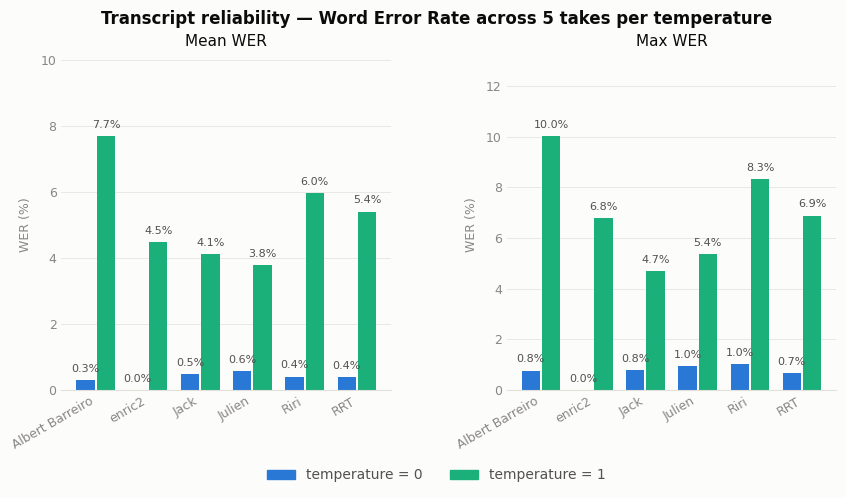

In [4]:
# ── Design tokens (validated default palette) ────────────────────────────────
C_TEMP0   = "#2a78d6"   # blue  — slot 1
C_TEMP1   = "#1baf7a"   # aqua  — slot 2  (below 3:1, direct labels applied)
SURFACE   = "#fcfcfb"
GRIDLINE  = "#e1e0d9"
MUTED     = "#898781"
PRIMARY   = "#0b0b0b"
SECONDARY = "#52514e"

metrics = [
    ("mean_wer", "Mean WER"),
    ("max_wer",  "Max WER"),
]

names  = list(wer_data.keys())
x      = np.arange(len(names))
W      = 0.35    # bar width
GAP    = 0.04    # gap between the two bars in a group
OFFSETS = [-(W + GAP) / 2, (W + GAP) / 2]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.35, bottom=0.22, top=0.88)

for ax, (metric_key, metric_label) in zip(axes, metrics):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    all_vals = [wer_data[n].get(t, {}).get(metric_key) for n in names for t in [0, 1]]
    all_vals = [v * 100 if v is not None else None for v in all_vals]
    y_max = max((v for v in all_vals if v is not None), default=0.1)

    for temp, color, offset in zip([0, 1], [C_TEMP0, C_TEMP1], OFFSETS):
        vals = [wer_data[n].get(temp, {}).get(metric_key) for n in names]
        vals = [v * 100 if v is not None else None for v in vals]
        heights = [v if v is not None else 0 for v in vals]
        bars = ax.bar(
            x + offset, heights, width=W,
            color=color, linewidth=0,
            label=f"temperature = {temp}",
        )
        for bar, v in zip(bars, vals):
            if v is not None:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_max * 0.025,
                    f"{v:.1f}%",
                    ha="center", va="bottom",
                    fontsize=8, color=SECONDARY,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9, color=MUTED)
    ax.tick_params(axis="y", labelsize=9, labelcolor=MUTED, length=0)
    ax.tick_params(axis="x", length=0)
    ax.set_ylim(0, y_max * 1.3)
    ax.set_title(metric_label, fontsize=11, color=PRIMARY, pad=10)
    ax.set_ylabel("WER (%)", fontsize=9, color=MUTED, labelpad=6)

legend_handles = [
    mpatches.Patch(color=C_TEMP0, label="temperature = 0"),
    mpatches.Patch(color=C_TEMP1, label="temperature = 1"),
]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=2,
    frameon=False, fontsize=10,
    labelcolor=SECONDARY, bbox_to_anchor=(0.5, 0.01),
)
fig.suptitle(
    "Transcript reliability — Word Error Rate across 5 takes per temperature",
    fontsize=12, color=PRIMARY, fontweight="semibold",
)

plt.show()